In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
SELECT uid, timestamp, numTrials
FROM checker
WHERE uid LIKE "user_%" AND status = "ready" AND labname = "project1"
"""
commits = pd.io.sql.read_sql(query, conn, parse_dates='timestamp')
commits.sort_values('uid', inplace=True)
commits

,uid,timestamp,numTrials
926,user_1,2020-05-14 21:21:00.651643,8
907,user_1,2020-05-14 21:12:49.812670,6
886,user_1,2020-05-14 20:56:08.898880,1
888,user_1,2020-05-14 20:58:46.322457,3
928,user_1,2020-05-14 21:23:00.570667,9
...,...,...,...
747,user_8,2020-05-14 15:50:51.715993,2
905,user_8,2020-05-14 21:12:17.314337,8
762,user_8,2020-05-14 16:11:00.491523,3
833,user_8,2020-05-14 17:40:47.781946,6


In [4]:
def mix_colors(color1, color2):
    return tuple([(x + y)/2 for x, y in zip(color1, color2)])

In [5]:
def remove_color(color1, color2):
    f_allowed = 1
    for x1, x2 in zip(color1, color2):
        for x0 in [0, 255]:
            if x2 == x0:
                continue
            f = (x1 - x0) / (x2 - x0)
            if not (0 <= f <= 1):
                continue
            f_allowed = min(f_allowed, f)
    return tuple([max((x1 - f_allowed*x2)/(1 - f_allowed), 0) for x1, x2 in zip(color1, color2)])

In [6]:
palette1 = sns.color_palette('tab20')
palette = []
for i in range(0, len(palette1), 2):
    color1 = palette1[i]
    color2 = palette1[i+1]
    color0 = remove_color(color1, color2)
    color3 = mix_colors(color1, color2)
    palette += [color0, mix_colors(color0, color2), color2]

/var/folders/59/pf5x3w3j4s35xm_nm3gd4_2c0000gn/T/ipykernel_26702/3217830736.py:4: UserWarning: The palette list has more values (30) than needed (27), which may not be intended.
  sns.lineplot(data=commits, x='timestamp', y='numTrials', hue='uid', ax=ax, linewidth=3, palette=palette)


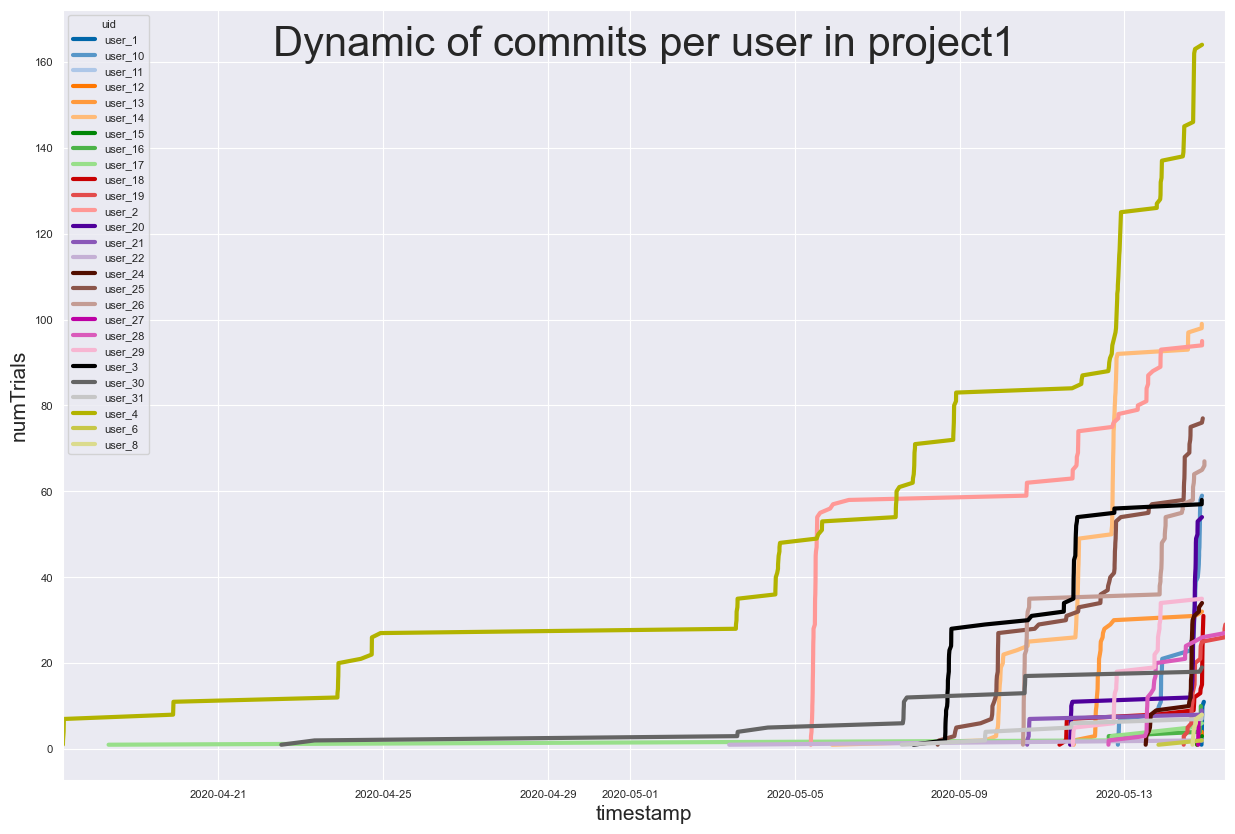

In [7]:
sns.set_style('darkgrid')
plt.rcParams.update({'font.size': 8, 'axes.labelsize': 15})
fig, ax = plt.subplots(figsize=(15, 10))
sns.lineplot(data=commits, x='timestamp', y='numTrials', hue='uid', ax=ax, linewidth=3, palette=palette)
ax.set_title('Dynamic of commits per user in project1', fontsize=30, pad=0, y=0.94)
ax.set_xmargin(0)
plt.show()

In [8]:
conn.close()

*answer: user_4*

*answer: user_2*